# Proyecto Finanzas: ML para Working Capital

**Objetivo**: agrupar empresas por su perfil de gestión de capital de trabajo, predecir niveles óptimos de activos corrientes, y simular ajustes operativos.

Pipeline completo en este notebook:
- **Módulo 0**: Descarga real desde Yahoo Finance (últimos 4 años fiscales por empresa) — sin imputación falsa.
- **Módulo 1**: Clustering K-means + validación con jerárquico aglomerativo.
- **Módulo 2**: Predicción del nivel óptimo de inventario / AR / cash basada en las mejores empresas de cada cluster.
- **Módulo 3**: Simulador interactivo 'qué pasa si' con sliders para DIO / DSO / DPO.

**Marco teórico**: gestión de capital de trabajo. CCC = DIO + DSO − DPO. CCC más bajo → mejor eficiencia, más cash libre.

## 1. Setup

In [19]:
#!pip install yfinance ipywidgets matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import time

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats.mstats import winsorize

import ipywidgets as widgets
from IPython.display import display, clear_output

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Configuración de tickers

Apuntamos a ~27 empresas distribuidas en 7 perfiles de capital de trabajo distintos. Solo descargamos los **últimos 4 años fiscales reales** de cada una (yfinance no expone histórico más profundo en su endpoint gratuito).

**Por qué estos sectores**: tienen estructuras de DIO/DSO/DPO muy distintas. Retail cobra al contado y financia con proveedores → DSO bajo, DPO alto. Industriales / farma → DSO alto, DIO alto. Tech → inventario muy bajo. Esa diversidad es lo que hace al clustering útil — si fueran todas retail, no habría nada que clusterizar.

In [20]:
TICKERS_CONFIG = {
    'Retail Tradicional':     ['WMT', 'TGT', 'COST', 'HD', 'KR', 'DG', 'DLTR'],
    'Fast Fashion / Apparel': ['ANF', 'GAP', 'URBN', 'TJX', 'ROST'],
    'Automotriz':             ['F', 'GM', 'TSLA'],
    'Tech Hardware':          ['AAPL', 'DELL', 'HPQ'],
    'Industriales':           ['CAT', 'DE'],
    'Farma':                  ['PFE', 'JNJ', 'MRK'],
    'Bebidas y Consumo':      ['KO', 'PEP'],
}

BALANCE_MAP = {
    'cash':                 ['Cash And Cash Equivalents', 'Cash', 'Cash Cash Equivalents And Short Term Investments'],
    'accounts_receivable':  ['Accounts Receivable', 'Receivables', 'Trade Receivables', 'Current Receivables'],
    'inventory':            ['Inventory', 'Inventories'],
    'accounts_payable':     ['Accounts Payable', 'Payables', 'Trade And Other Payables Current', 'Current Accounts Payable'],
    'current_assets':       ['Current Assets', 'Total Current Assets'],
    'current_liabilities':  ['Current Liabilities', 'Total Current Liabilities'],
    'total_assets':         ['Total Assets'],
}
INCOME_MAP = {
    'revenue': ['Total Revenue', 'Operating Revenue', 'Net Revenue'],
    'cogs':    ['Cost Of Revenue', 'Cost Of Goods Sold', 'Reconciled Cost Of Revenue'],
}

total_empresas = sum(len(v) for v in TICKERS_CONFIG.values())
print(f'Empresas configuradas: {total_empresas}')
print(f'Sectores: {len(TICKERS_CONFIG)}')
print(f'Observaciones objetivo (~4 años fiscales c/u): ~{total_empresas * 4}')

Empresas configuradas: 25
Sectores: 7
Observaciones objetivo (~4 años fiscales c/u): ~100


## 3. Descarga de datos reales

**Diferencia clave vs. versión anterior**: en lugar de iterar por años objetivo (2015–2025) y rellenar huecos con la media (lo que producía filas idénticas duplicadas y enmascaraba que ~70% del dataset era sintético), aquí iteramos por las **fechas reales** que devuelve yfinance. Tomamos los últimos 4 años fiscales disponibles. Si falta un dato crítico (revenue, COGS, inventario, AR, AP), **descartamos** esa observación en vez de imputar.

Resultado: dataset 100% real, aunque más pequeño.

In [21]:
def extraer_serie(df, alias_list):
    """Devuelve la primera serie que matchee alguno de los alias en el índice del DataFrame."""
    if df is None or df.empty:
        return None
    for alias in alias_list:
        if alias in df.index:
            return df.loc[alias]
    return None


def descargar_empresa(ticker, sector, max_intentos=2):
    """Descarga balance + income de una empresa y devuelve una fila por año fiscal con data completa."""
    bs, inc = None, None
    for intento in range(max_intentos):
        try:
            t = yf.Ticker(ticker)
            bs = t.balance_sheet
            inc = t.income_stmt
            if bs is not None and inc is not None and not bs.empty and not inc.empty:
                break
            time.sleep(1.5)
        except Exception as e:
            print(f'  ⚠️  {ticker} intento {intento+1}: {e}')
            time.sleep(2)
    if bs is None or inc is None or bs.empty or inc.empty:
        print(f'  ✗ {ticker}: descarga fallida')
        return None

    fechas_comunes = sorted(set(bs.columns) & set(inc.columns), reverse=True)[:4]
    if not fechas_comunes:
        print(f'  ✗ {ticker}: sin fechas comunes entre balance e income')
        return None

    # Extrae las series una vez por variable
    series_bs = {nombre: extraer_serie(bs, aliases) for nombre, aliases in BALANCE_MAP.items()}
    series_inc = {nombre: extraer_serie(inc, aliases) for nombre, aliases in INCOME_MAP.items()}
    series = {**series_bs, **series_inc}

    filas = []
    for fecha in fechas_comunes:
        fila = {'ticker': ticker, 'sector': sector, 'fiscal_year': fecha.year}
        for nombre, serie in series.items():
            if serie is None:
                fila[nombre] = np.nan
            else:
                val = serie.get(fecha, np.nan)
                fila[nombre] = float(val) if pd.notna(val) else np.nan
        criticos = ['revenue', 'cogs', 'inventory', 'accounts_receivable', 'accounts_payable']
        if any(pd.isna(fila[c]) for c in criticos):
            continue
        filas.append(fila)

    if not filas:
        print(f'  ✗ {ticker}: 0 años con data completa (falta algún campo crítico)')
        return None

    print(f'  ✓ {ticker}: {len(filas)} año(s) con data completa')
    return pd.DataFrame(filas)

In [22]:
print('='*70)
print('DESCARGA DE DATOS FINANCIEROS REALES')
print('='*70)
print(f'Inicio: {datetime.now():%Y-%m-%d %H:%M:%S}\n')

dfs = []
for sector, tickers in TICKERS_CONFIG.items():
    print(f'\n--- {sector} ---')
    for ticker in tickers:
        df_emp = descargar_empresa(ticker, sector)
        if df_emp is not None:
            dfs.append(df_emp)

if not dfs:
    raise RuntimeError('Pipeline fallido: ninguna empresa con data completa')

df_raw = pd.concat(dfs, ignore_index=True)

print('\n' + '='*70)
print(f'RESULTADO: {len(df_raw)} observaciones reales de {df_raw["ticker"].nunique()} empresas')
print('='*70)
print(df_raw.groupby('sector')['ticker'].agg(['nunique', 'count']).rename(
    columns={'nunique': 'empresas', 'count': 'obs_totales'}))

DESCARGA DE DATOS FINANCIEROS REALES
Inicio: 2026-05-21 17:20:07


--- Retail Tradicional ---
  ✓ WMT: 4 año(s) con data completa
  ✓ TGT: 4 año(s) con data completa
  ✓ COST: 4 año(s) con data completa
  ✓ HD: 4 año(s) con data completa
  ✓ KR: 4 año(s) con data completa
  ✓ DG: 4 año(s) con data completa
  ✗ DLTR: 0 años con data completa (falta algún campo crítico)

--- Fast Fashion / Apparel ---
  ✓ ANF: 4 año(s) con data completa
  ✓ GAP: 4 año(s) con data completa
  ✓ URBN: 4 año(s) con data completa
  ✓ TJX: 4 año(s) con data completa
  ✓ ROST: 4 año(s) con data completa

--- Automotriz ---
  ✓ F: 4 año(s) con data completa
  ✓ GM: 4 año(s) con data completa
  ✓ TSLA: 4 año(s) con data completa

--- Tech Hardware ---
  ✓ AAPL: 4 año(s) con data completa
  ✓ DELL: 4 año(s) con data completa
  ✓ HPQ: 4 año(s) con data completa

--- Industriales ---
  ✓ CAT: 4 año(s) con data completa
  ✓ DE: 4 año(s) con data completa

--- Farma ---
  ✓ PFE: 4 año(s) con data completa
  ✓ JNJ: 4 a

## 4. Cálculo de ratios

Calculamos los 7 features que pide el instructivo. **Importante**: DPO usa cuentas por pagar (AP) reales — no pasivo corriente. Ese error en la versión anterior hacía que DPO fuera ~100 días en promedio (DPO real corporativo está entre 30 y 60) y producía CCC negativos artificiales en casi todo el dataset.

- **DIO** = (Inventario / COGS) × 365 — días para vender el inventario
- **DSO** = (AR / Revenue) × 365 — días para cobrar
- **DPO** = (AP / COGS) × 365 — días para pagar a proveedores
- **CCC** = DIO + DSO − DPO — días que el cash queda atrapado en operación
- **% sobre activos corrientes**: cash, AR e inventario

In [23]:
def calcular_ratios(df):
    df = df.copy()
    df['dio'] = (df['inventory'] / df['cogs']) * 365
    df['dso'] = (df['accounts_receivable'] / df['revenue']) * 365
    df['dpo'] = (df['accounts_payable'] / df['cogs']) * 365
    df['ccc'] = df['dio'] + df['dso'] - df['dpo']

    df['cash_pct']        = (df['cash']                / df['current_assets']) * 100
    df['receivables_pct'] = (df['accounts_receivable'] / df['current_assets']) * 100
    df['inventory_pct']   = (df['inventory']           / df['current_assets']) * 100

    for c in ['dio', 'dso', 'dpo', 'ccc', 'cash_pct', 'receivables_pct', 'inventory_pct']:
        df[c] = df[c].round(2)
    return df

df = calcular_ratios(df_raw)

cols_id = ['ticker', 'sector', 'fiscal_year']
cols_abs = ['revenue', 'cogs', 'cash', 'accounts_receivable', 'inventory',
            'accounts_payable', 'current_assets', 'current_liabilities', 'total_assets']
cols_ratios = ['cash_pct', 'receivables_pct', 'inventory_pct', 'dso', 'dio', 'dpo', 'ccc']
df = df[cols_id + cols_ratios + cols_abs]

df.to_csv('dataset_finanzas_real.csv', index=False)
print(f'✓ CSV guardado: dataset_finanzas_real.csv ({len(df)} filas)\n')

print('Estadísticos de los ratios:')
print(df[cols_ratios].describe().round(2))
df.head(10)

✓ CSV guardado: dataset_finanzas_real.csv (96 filas)

Estadísticos de los ratios:
       cash_pct  receivables_pct  inventory_pct     dso     dio     dpo  \
count     96.00            96.00          96.00   96.00   96.00   96.00   
mean      25.14            18.34          35.68   34.08   74.11   70.22   
std       14.97            14.75          22.17   37.37   45.98   33.75   
min        0.81             0.22           3.65    0.15    8.08   26.90   
25%       14.51             6.50          17.92    5.14   40.72   41.64   
50%       21.07            13.40          33.39   20.37   61.67   61.16   
75%       35.46            26.92          47.48   49.30   89.95   98.13   
max       65.92            54.53          89.18  131.35  242.03  150.07   

          ccc  
count   96.00  
mean    37.97  
std     59.92  
min    -75.83  
25%      1.99  
50%     27.86  
75%     82.34  
max    192.25  


,ticker,sector,fiscal_year,cash_pct,receivables_pct,inventory_pct,dso,dio,dpo,ccc,revenue,cogs,cash,accounts_receivable,inventory,accounts_payable,current_assets,current_liabilities,total_assets
0,WMT,Retail Tradicional,2026,12.64,13.16,69.34,5.72,40.12,42.99,2.85,7.131630e+11,5.353950e+11,1.072700e+10,1.117200e+10,5.885100e+10,6.306100e+10,8.487400e+10,1.074690e+11,2.846680e+11
1,WMT,Retail Tradicional,2025,11.37,12.55,71.02,5.35,40.25,41.84,3.76,6.809850e+11,5.117530e+11,9.037000e+09,9.975000e+09,5.643500e+10,5.866600e+10,7.945800e+10,9.658400e+10,2.608230e+11
2,WMT,Retail Tradicional,2024,12.83,11.44,71.40,4.95,40.88,42.31,3.52,6.481250e+11,4.901420e+11,9.867000e+09,8.796000e+09,5.489200e+10,5.681200e+10,7.687700e+10,9.241500e+10,2.523990e+11
3,WMT,Retail Tradicional,2023,11.40,10.49,74.78,4.74,44.53,42.30,6.97,6.112890e+11,4.637210e+11,8.625000e+09,7.933000e+09,5.657600e+10,5.374200e+10,7.565500e+10,9.219800e+10,2.431970e+11
4,TGT,Retail Tradicional,2026,27.43,6.32,61.50,4.41,59.47,61.01,2.87,1.047800e+11,7.551100e+10,5.488000e+09,1.265000e+09,1.230400e+10,1.262200e+10,2.000500e+10,2.123000e+10,5.949000e+10
5,TGT,Retail Tradicional,2025,24.48,5.13,65.49,3.42,60.78,62.28,1.92,1.065660e+11,7.650200e+10,4.762000e+09,9.980000e+08,1.274000e+10,1.305300e+10,1.945400e+10,2.079900e+10,5.776900e+10
6,TGT,Retail Tradicional,2024,21.75,5.09,67.93,3.03,55.74,56.74,2.03,1.074120e+11,7.782800e+10,3.805000e+09,8.910000e+08,1.188600e+10,1.209800e+10,1.749800e+10,1.930400e+10,5.535600e+10
7,TGT,Retail Tradicional,2023,12.49,6.55,75.64,3.91,59.86,59.81,3.96,1.091200e+11,8.230600e+10,2.229000e+09,1.169000e+09,1.349900e+10,1.348700e+10,1.784600e+10,1.950000e+10,5.333500e+10
8,COST,Retail Tradicional,2025,36.90,8.35,47.20,4.25,27.56,30.10,1.71,2.752350e+11,2.398860e+11,1.416100e+10,3.203000e+09,1.811600e+10,1.978300e+10,3.838000e+10,3.710800e+10,7.709900e+10
9,COST,Retail Tradicional,2024,28.93,7.95,54.45,3.90,30.61,31.88,2.63,2.544530e+11,2.223580e+11,9.906000e+09,2.721000e+09,1.864700e+10,1.942100e+10,3.424600e+10,3.546400e+10,6.983100e+10


## 5. EDA: distribución de features y outliers

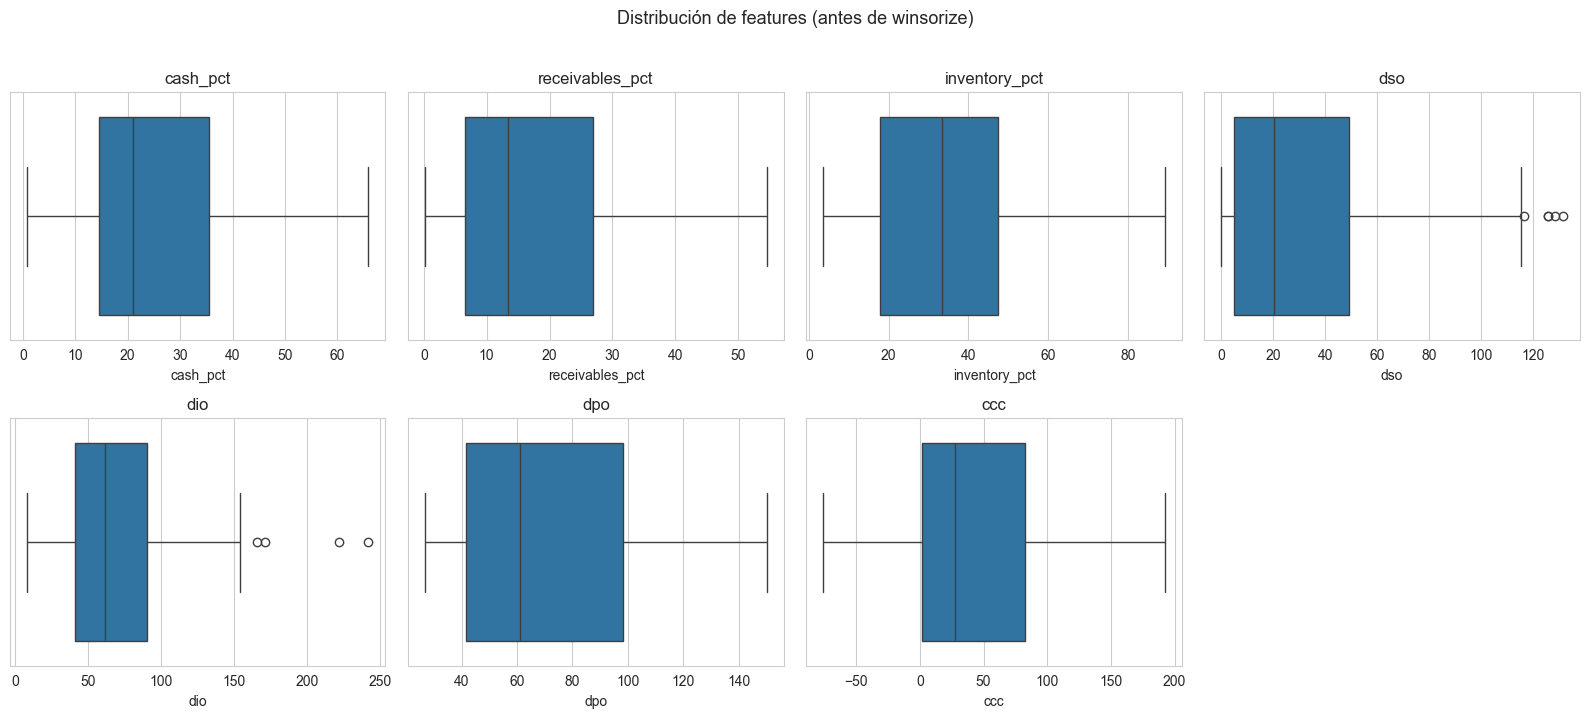

In [24]:
features = ['cash_pct', 'receivables_pct', 'inventory_pct', 'dso', 'dio', 'dpo', 'ccc']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
axes[-1].axis('off')
plt.suptitle('Distribución de features (antes de winsorize)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 6. Tratamiento de outliers: winsorización

Reemplazamos los valores en el 2.5% superior e inferior de cada variable por los percentiles 2.5 y 97.5, para que K-means (basado en distancias euclidianas) no se vea dominado por casos atípicos (ej. Tesla con DSO muy bajo, o algún año con AR inflado por una unidad atípica).

**Nota sobre la versión anterior**: usaban `limits=[0.066, 0.66]`, que recortaba el **66% superior** de cada variable — eso no era winsorización, era destruir la distribución. Aquí usamos los límites correctos.

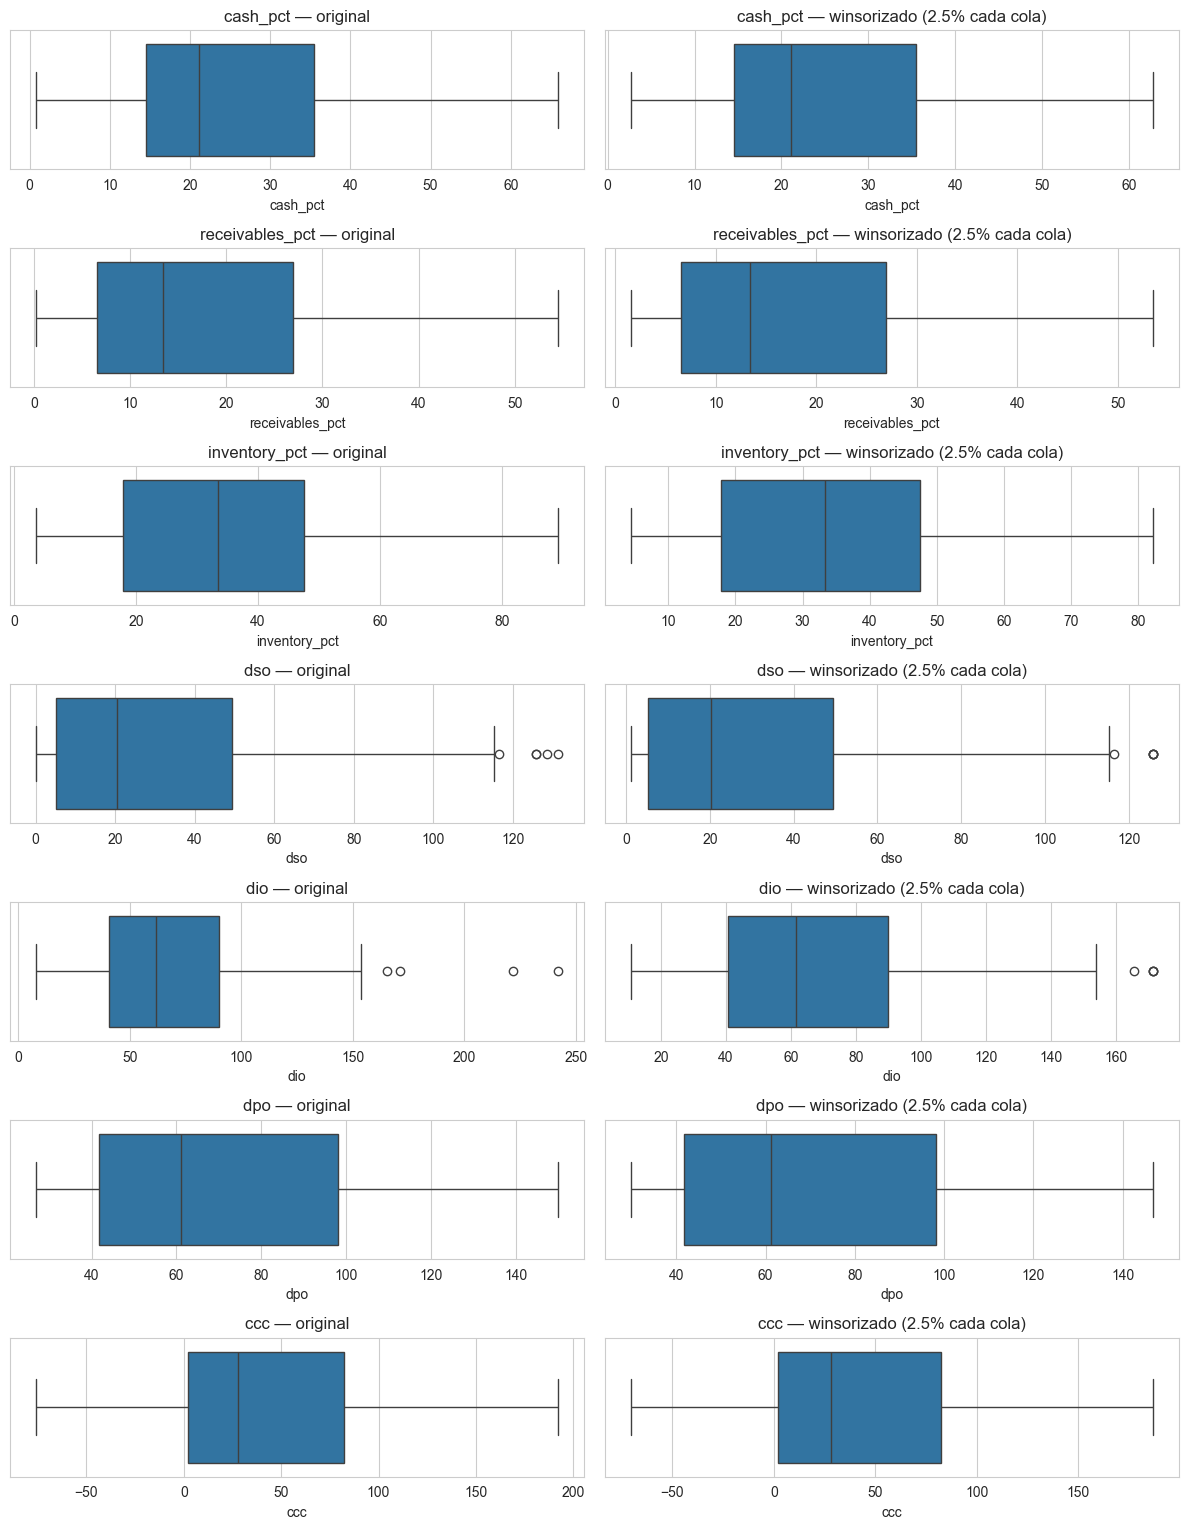

In [25]:
X_wins = df[features].copy()
for col in features:
    X_wins[col] = winsorize(X_wins[col], limits=[0.025, 0.025])

fig, axes = plt.subplots(len(features), 2, figsize=(12, 2.2*len(features)))
for i, col in enumerate(features):
    sns.boxplot(x=df[col], ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} — original')
    sns.boxplot(x=X_wins[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} — winsorizado (2.5% cada cola)')
plt.tight_layout()
plt.show()

## 7. Escalado robusto

`RobustScaler` usa mediana e IQR en lugar de media y desvío. Más apropiado para ratios financieros que aún tienen colas largas después de winsorizar.

In [26]:
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_wins), columns=features)
print('Resumen de features escaladas:')
print(X_scaled.describe().round(2))

Resumen de features escaladas:
       cash_pct  receivables_pct  inventory_pct    dso    dio    dpo    ccc
count     96.00            96.00          96.00  96.00  96.00  96.00  96.00
mean       0.19             0.24           0.07   0.31   0.23   0.16   0.13
std        0.70             0.72           0.74   0.84   0.86   0.59   0.74
min       -0.88            -0.58          -0.98  -0.44  -1.03  -0.56  -1.22
25%       -0.31            -0.34          -0.52  -0.34  -0.43  -0.35  -0.32
50%        0.00             0.00           0.00   0.00   0.00   0.00   0.00
75%        0.69             0.66           0.48   0.66   0.57   0.65   0.68
max        1.99             1.96           1.65   2.39   2.22   1.52   1.98


## 8. Selección del número de clusters (k)

Probamos k = 2 … 8 y miramos dos métricas:

- **Inercia (codo)**: suma de distancias al cuadrado dentro de cada cluster. Buscamos el punto donde sumar otro cluster ya no reduce mucho la inercia.
- **Silhouette**: cuán bien separados están los clusters (rango −1 a +1). Más alto = mejor.

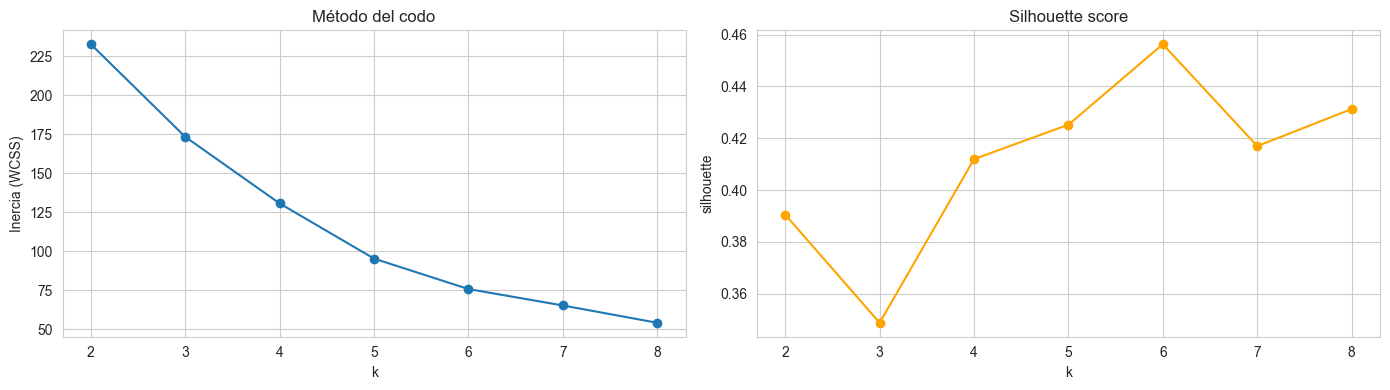

 k  inercia  silhouette
 2  232.657       0.390
 3  173.312       0.349
 4  130.599       0.412
 5   95.222       0.425
 6   75.695       0.456
 7   65.188       0.417
 8   54.076       0.431


In [27]:
K_range = range(2, 9)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia (WCSS)'); axes[0].grid(True)
axes[1].plot(list(K_range), silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('silhouette'); axes[1].grid(True)
plt.tight_layout(); plt.show()

resumen_k = pd.DataFrame({'k': list(K_range), 'inercia': inertias, 'silhouette': silhouettes}).round(3)
print(resumen_k.to_string(index=False))

## 9. Elección final de k

Por defecto elegimos el k con silhouette máximo. Si los plots sugieren otro valor por motivos de interpretabilidad, editar la celda siguiente (`optimal_k = ...`).

In [28]:
optimal_k = int(resumen_k.loc[resumen_k['silhouette'].idxmax(), 'k'])
print(f'k seleccionado automáticamente por silhouette: k = {optimal_k}')
print('(Si querés forzar otro, sobrescribí: optimal_k = 4 por ejemplo)')

k seleccionado automáticamente por silhouette: k = 6
(Si querés forzar otro, sobrescribí: optimal_k = 4 por ejemplo)


## 10. K-means final + visualización PCA

Distribución de observaciones por cluster:
cluster
0    15
1    16
2    25
3     8
4    27
5     5
Name: count, dtype: int64

Varianza explicada PC1/PC2: [0.454 0.234]
Acumulada: 0.688

Loadings (contribución de cada feature a PC1/PC2):
                   PC1    PC2
cash_pct        -0.116 -0.004
receivables_pct  0.451 -0.326
inventory_pct   -0.336  0.378
dso              0.598 -0.190
dio              0.326  0.711
dpo              0.202 -0.121
ccc              0.408  0.442


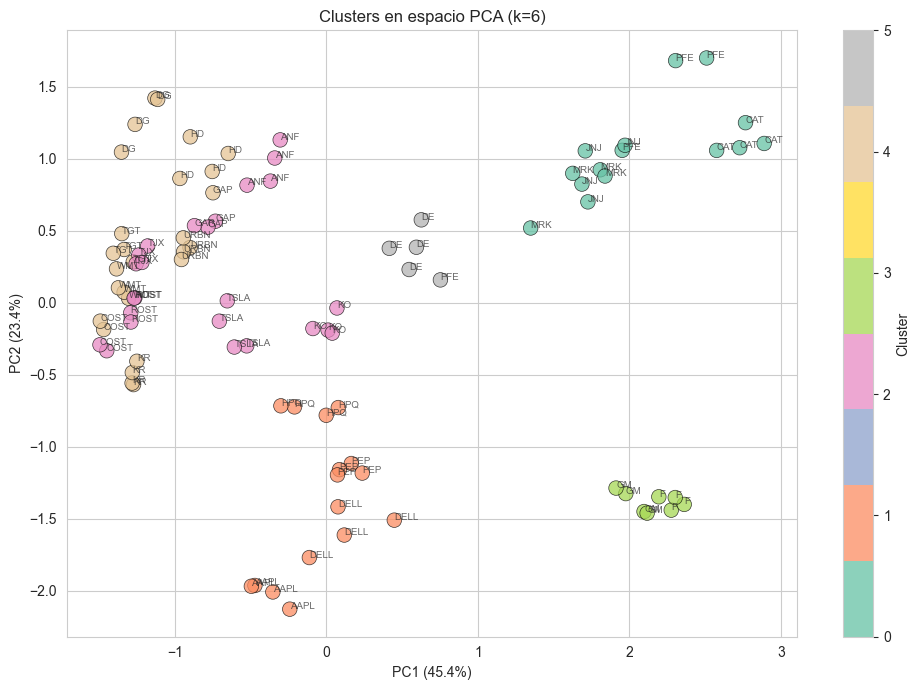

In [29]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f'Distribución de observaciones por cluster:\n{df["cluster"].value_counts().sort_index()}\n')

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'Varianza explicada PC1/PC2: {pca.explained_variance_ratio_.round(3)}')
print(f'Acumulada: {pca.explained_variance_ratio_.sum():.3f}\n')

loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features).round(3)
print('Loadings (contribución de cada feature a PC1/PC2):')
print(loadings)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='Set2',
                     s=110, alpha=0.75, edgecolors='black', linewidths=0.5)
for i, row in df.reset_index().iterrows():
    ax.annotate(row['ticker'], (X_pca[i, 0], X_pca[i, 1]), fontsize=7, alpha=0.7)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'Clusters en espacio PCA (k={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout(); plt.show()

## 11. Validación con clustering jerárquico

Comparamos K-means con clustering jerárquico aglomerativo (linkage = ward) y cuantificamos el acuerdo entre ambos con el **Adjusted Rand Index (ARI)**.

- ARI = 1 → acuerdo perfecto
- ARI ≥ 0.7 → buena consistencia
- ARI ≤ 0.3 → métodos discrepan (revisar k o features)

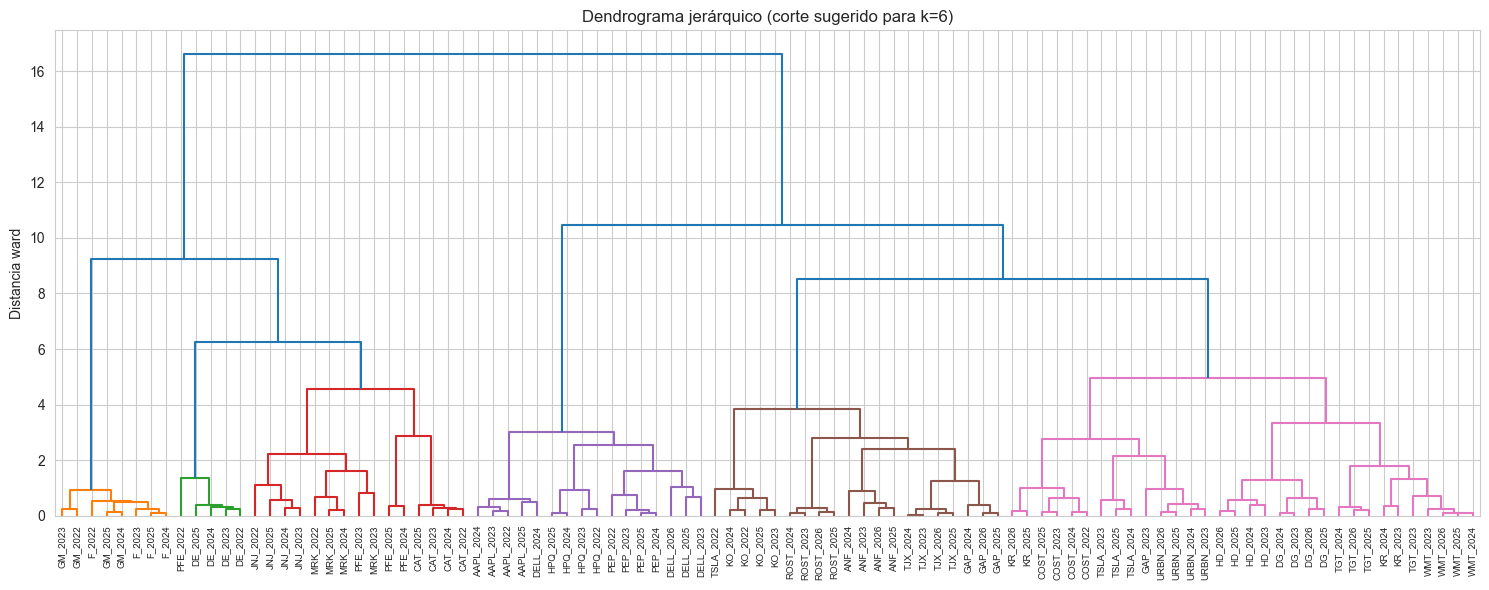


ARI K-means vs jerárquico: 0.841
✓ Acuerdo alto: los clusters son consistentes entre ambos métodos.


In [30]:
linked = linkage(X_scaled, method='ward')

labels_dendro = [f'{t}_{int(y)}' for t, y in zip(df['ticker'], df['fiscal_year'])]
color_threshold = linked[-(optimal_k-1), 2] if optimal_k > 1 else None

fig, ax = plt.subplots(figsize=(15, 6))
dendrogram(linked, labels=labels_dendro, leaf_font_size=7, color_threshold=color_threshold)
ax.set_title(f'Dendrograma jerárquico (corte sugerido para k={optimal_k})')
ax.set_ylabel('Distancia ward')
plt.xticks(rotation=90)
plt.tight_layout(); plt.show()

hier_labels = fcluster(linked, t=optimal_k, criterion='maxclust')
ari = adjusted_rand_score(df['cluster'], hier_labels)
print(f'\nARI K-means vs jerárquico: {ari:.3f}')
if ari >= 0.7:
    print('✓ Acuerdo alto: los clusters son consistentes entre ambos métodos.')
elif ari >= 0.4:
    print('⚠️  Acuerdo moderado: forma similar pero con divergencias en los bordes.')
else:
    print('✗ Acuerdo bajo: los métodos discrepan. Revisar k o features.')

## 12. Perfil de cada cluster

Los centroides (promedio de features por cluster) dicen qué tipo de empresa representa cada grupo. Interpretación financiera:

- **DSO bajo + DPO alto + CCC negativo** → caja muy eficiente (cobra rápido, paga lento). Retail moderno (WMT, COST).
- **DIO alto** → inventario lento. Autos, industriales, retail tradicional.
- **DSO alto** → mucha venta a crédito. B2B, industriales, farma.
- **Cash_pct alto** → conservadora, mantiene liquidez.

Centroides por cluster:
         cash_pct  receivables_pct  inventory_pct     dso     dio     dpo  \
cluster                                                                     
0           22.89            30.88          24.56   76.11  159.32  103.17   
1           21.44            27.33          19.50   35.36   37.46  112.27   
2           44.08             6.67          33.67   10.33   73.28   63.42   
3           19.32            51.13          13.45  120.04   34.74   59.61   
4           15.99             8.49          64.25    4.85   58.22   41.44   
5            7.70            11.13          12.18   43.00   88.70   43.17   

            ccc  n_obs  
cluster                 
0        132.26     15  
1        -39.45     16  
2         20.18     25  
3         95.17      8  
4         21.63     27  
5         88.52      5  

Empresas en cada cluster:
  Cluster 0: CAT, JNJ, MRK, PFE
  Cluster 1: AAPL, DELL, HPQ, PEP
  Cluster 2: ANF, COST, GAP, KO, ROST, TJX, TSLA
  Cluster 3: F, G

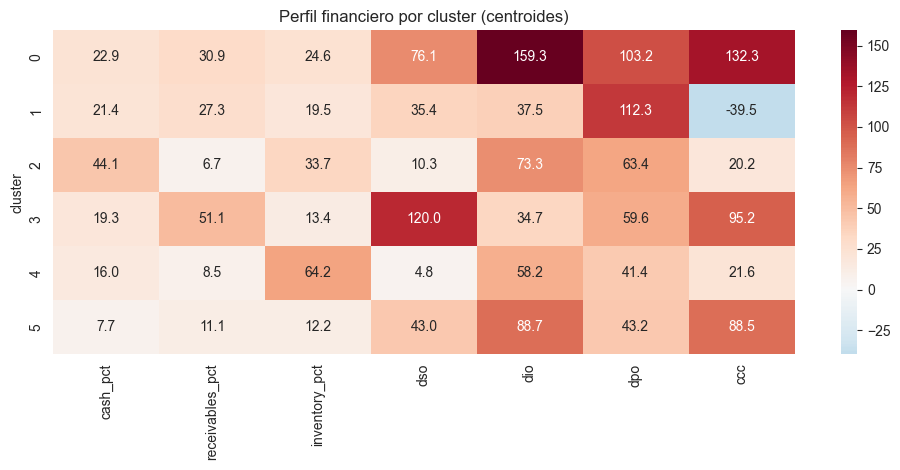

In [31]:
cluster_profile = df.groupby('cluster')[features].mean().round(2)
cluster_profile['n_obs'] = df.groupby('cluster').size()
cluster_profile['empresas'] = df.groupby('cluster')['ticker'].apply(lambda x: ', '.join(sorted(set(x))))

print('Centroides por cluster:')
print(cluster_profile[features + ['n_obs']])
print('\nEmpresas en cada cluster:')
for c in sorted(cluster_profile.index):
    print(f'  Cluster {c}: {cluster_profile.loc[c, "empresas"]}')

plt.figure(figsize=(10, max(4, optimal_k * 0.8)))
sns.heatmap(cluster_profile[features], annot=True, fmt='.1f', cmap='RdBu_r', center=0)
plt.title('Perfil financiero por cluster (centroides)')
plt.tight_layout(); plt.show()

## 13. Cluster más eficiente

Definimos al cluster más eficiente como el de **menor CCC promedio**. Es la métrica directa de gestión de capital de trabajo según el marco teórico.

In [32]:
cluster_eficiente = int(cluster_profile['ccc'].idxmin())
ccc_objetivo = float(cluster_profile.loc[cluster_eficiente, 'ccc'])
print(f'Cluster más eficiente: {cluster_eficiente}')
print(f'  CCC promedio: {ccc_objetivo:.1f} días')
print(f'  Empresas: {cluster_profile.loc[cluster_eficiente, "empresas"]}')

Cluster más eficiente: 1
  CCC promedio: -39.5 días
  Empresas: AAPL, DELL, HPQ, PEP


---
# MODULO 2 - Prediccion del nivel optimo

**Objetivo**: para una empresa dada, estimar cuanto inventario / AR / AP deberia tener si gestionara su working capital como las mejores de su cluster.

**Enfoque (corregido)**: predecimos **ratios operativos** (DIO, DSO, DPO objetivo) y los convertimos a USD usando el revenue y COGS actuales de la empresa.

- DIO_target = mediana de DIO del top-30% del cluster (por menor CCC)
- Inventario_optimo = DIO_target x COGS_actual / 365
- Idem para DSO -> AR_optimo, y DPO -> AP_optimo

**Por que cambiamos respecto a Ridge en valores absolutos**:
- Los optimos jamas pueden ser negativos por construccion.
- No extrapola fuera del rango de la muestra (CAT ya no recibe cash optimo de -$115B).
- Coincide con el marco teorico: las metricas operativas son ratios, no montos.
- Es interpretable: "tu inventario optimo equivale a X dias de COGS porque las mejores del cluster estan en X dias".


In [33]:
def calcular_targets_por_cluster(df, top_pct=0.30):
    """Para cada cluster, calcula los target ratios (DIO/DSO/DPO/CCC)
    como la mediana del top-30% por menor CCC.
    """
    targets = {}
    for c in sorted(df["cluster"].unique()):
        sub = df[df["cluster"] == c]
        n_top = max(3, int(len(sub) * top_pct))
        top = sub.nsmallest(n_top, "ccc")
        targets[c] = {
            "dio_target": float(top["dio"].median()),
            "dso_target": float(top["dso"].median()),
            "dpo_target": float(top["dpo"].median()),
            "ccc_target": float(top["ccc"].median()),
            "n_train": n_top,
        }
    return targets


def predecir_niveles_optimos(empresa_row, targets_por_cluster):
    """Calcula niveles optimos absolutos usando target ratios x revenue/COGS actuales."""
    c = int(empresa_row["cluster"])
    t = targets_por_cluster[c]

    cogs = float(empresa_row["cogs"])
    revenue = float(empresa_row["revenue"])

    inv_optimo = t["dio_target"] * cogs / 365
    ar_optimo  = t["dso_target"] * revenue / 365
    ap_optimo  = t["dpo_target"] * cogs / 365

    inv_actual = float(empresa_row["inventory"])
    ar_actual  = float(empresa_row["accounts_receivable"])
    ap_actual  = float(empresa_row["accounts_payable"])

    return {
        "ticker": empresa_row["ticker"],
        "fiscal_year": int(empresa_row["fiscal_year"]),
        "cluster": c,
        "dio_actual": float(empresa_row["dio"]),
        "dio_target": t["dio_target"],
        "dso_actual": float(empresa_row["dso"]),
        "dso_target": t["dso_target"],
        "dpo_actual": float(empresa_row["dpo"]),
        "dpo_target": t["dpo_target"],
        "ccc_actual": float(empresa_row["ccc"]),
        "ccc_target": t["ccc_target"],
        "inv_actual": inv_actual, "inv_optimo": inv_optimo, "inv_gap": inv_actual - inv_optimo,
        "ar_actual":  ar_actual,  "ar_optimo":  ar_optimo,  "ar_gap":  ar_actual - ar_optimo,
        "ap_actual":  ap_actual,  "ap_optimo":  ap_optimo,  "ap_gap":  ap_actual - ap_optimo,
    }


targets_por_cluster = calcular_targets_por_cluster(df, top_pct=0.30)
print("Targets por cluster (mediana del top-30% por menor CCC):")
header = f"{'cluster':>8} {'DIO_t':>8} {'DSO_t':>8} {'DPO_t':>8} {'CCC_t':>8} {'n_train':>8}"
print(header)
for c, t in targets_por_cluster.items():
    print(f"{c:>8} {t['dio_target']:>8.1f} {t['dso_target']:>8.1f} {t['dpo_target']:>8.1f} {t['ccc_target']:>8.1f} {t['n_train']:>8}")


Targets por cluster (mediana del top-30% por menor CCC):
 cluster    DIO_t    DSO_t    DPO_t    CCC_t  n_train
       0    153.0     62.4    134.7     87.2        4
       1     10.1     29.6    111.1    -70.8        4
       2     77.3     13.2     91.9      2.0        7
       3     39.4    109.3     67.2     81.4        3
       4     27.1      5.3     33.2     -0.4        8
       5     84.7     39.5     33.4     91.9        3


In [34]:
# Aplicar a la ultima observacion de cada empresa
ultima_por_empresa = df.sort_values("fiscal_year").drop_duplicates("ticker", keep="last")

resultados = [predecir_niveles_optimos(row, targets_por_cluster) for _, row in ultima_por_empresa.iterrows()]
df_resultados = pd.DataFrame(resultados)

# Vista 1: ratios actuales vs target (dias)
vista_ratios = df_resultados[["ticker", "cluster",
                              "dio_actual", "dio_target",
                              "dso_actual", "dso_target",
                              "dpo_actual", "dpo_target",
                              "ccc_actual", "ccc_target"]].round(1)
print("=== Ratios actuales vs target (dias) ===")
print(vista_ratios.to_string(index=False))

# Vista 2: niveles absolutos en USD millones
vista_dolares = df_resultados[["ticker", "cluster",
                               "inv_actual", "inv_optimo", "inv_gap",
                               "ar_actual",  "ar_optimo",  "ar_gap",
                               "ap_actual",  "ap_optimo",  "ap_gap"]].copy()
for c in vista_dolares.columns:
    if c not in ["ticker", "cluster"]:
        vista_dolares[c] = (vista_dolares[c] / 1e6).round(0)
vista_dolares.columns = ["ticker", "cluster",
                         "inv_act_M", "inv_opt_M", "inv_gap_M",
                         "AR_act_M",  "AR_opt_M",  "AR_gap_M",
                         "AP_act_M",  "AP_opt_M",  "AP_gap_M"]
print()
print("=== Niveles absolutos en USD millones (gap positivo = sobra capital atrapado) ===")
print(vista_dolares.to_string(index=False))


=== Ratios actuales vs target (dias) ===
ticker  cluster  dio_actual  dio_target  dso_actual  dso_target  dpo_actual  dpo_target  ccc_actual  ccc_target
  COST        2        27.6        77.3         4.2        13.2        30.1        91.9         1.7         2.0
   PFE        0       242.0       153.0        69.3        62.4       119.0       134.7       192.2        87.2
    DE        5        96.6        84.7        44.0        39.5        38.4        33.4       102.2        91.9
   HPQ        1        70.8        10.1        37.6        29.6       150.1       111.1       -41.7       -70.8
     F        3        30.1        39.4       125.8       109.4        50.8        67.2       105.1        81.4
    GM        3        30.4        39.4       115.0       109.4        50.3        67.2        95.2        81.4
  AAPL        1         9.4        10.1        34.9        29.6       115.4       111.1       -71.1       -70.8
  TSLA        2        58.2        77.3        17.6        13.2

---
# MODULO 3 - Simulador 'que pasa si'

Sliders para ajustar DIO, DSO y DPO de una empresa, y ver:

1. **CCC nuevo** = DIO + DSO - DPO
2. **Cash liberado** ~ delta_CCC x (revenue / 365)
3. **Receta sugerida** para llegar al target del **propio cluster** (no al cluster eficiente global, que seria irrealista para industrias muy distintas).

**Fixes respecto a la version previa**:
- Target = top-30% del **propio cluster** de la empresa. CAT no se compara con AAPL.
- Limites fisicos en la receta: `DIO >= 5`, `DSO >= 0`, `DPO en [5, 120]`. No mas dias negativos ni DPO de 200 dias.
- Si las 3 palancas tocan limite y aun queda brecha, se reporta como **brecha estructural**: no se puede cerrar solo con palancas operativas.


In [35]:
import ipywidgets as widgets
from IPython.display import display

# Limites fisicos para palancas operativas
DIO_MIN, DIO_MAX = 5, 365
DSO_MIN, DSO_MAX = 0, 200
DPO_MIN, DPO_MAX = 5, 120


def clip_a_factible(dio, dso, dpo):
    return (max(DIO_MIN, min(DIO_MAX, dio)),
            max(DSO_MIN, min(DSO_MAX, dso)),
            max(DPO_MIN, min(DPO_MAX, dpo)))


def simular(ticker="WMT"):
    if ticker not in df["ticker"].values:
        print("Ticker", ticker, "no esta en el dataset.")
        print("Disponibles:", sorted(df["ticker"].unique()))
        return

    emp = df[df["ticker"] == ticker].sort_values("fiscal_year").iloc[-1]
    dio_a = float(emp["dio"])
    dso_a = float(emp["dso"])
    dpo_a = float(emp["dpo"])
    ccc_a = float(emp["ccc"])
    rev = float(emp["revenue"])
    c = int(emp["cluster"])

    # Targets del PROPIO cluster
    t = targets_por_cluster[c]
    dio_t_raw = t["dio_target"]
    dso_t_raw = t["dso_target"]
    dpo_t_raw = t["dpo_target"]

    dio_t, dso_t, dpo_t = clip_a_factible(dio_t_raw, dso_t_raw, dpo_t_raw)
    ccc_t_factible = dio_t + dso_t - dpo_t

    dio_s = widgets.FloatSlider(value=dio_a, min=0, max=500, step=1,
                                description="DIO:", continuous_update=False,
                                style={"description_width": "60px"},
                                layout=widgets.Layout(width="500px"))
    dso_s = widgets.FloatSlider(value=dso_a, min=0, max=300, step=1,
                                description="DSO:", continuous_update=False,
                                style={"description_width": "60px"},
                                layout=widgets.Layout(width="500px"))
    dpo_s = widgets.FloatSlider(value=dpo_a, min=0, max=300, step=1,
                                description="DPO:", continuous_update=False,
                                style={"description_width": "60px"},
                                layout=widgets.Layout(width="500px"))

    out = widgets.Output()

    def _mostrar(DIO, DSO, DPO):
        with out:
            out.clear_output(wait=True)
            ccc_n = DIO + DSO - DPO
            cash_liberado = (ccc_a - ccc_n) * (rev / 365)

            sector = emp["sector"]
            anio = int(emp["fiscal_year"])
            print(f"Empresa: {ticker} | Sector: {sector} | Cluster: {c} | Anio: {anio}")
            rev_b = rev / 1e9
            print(f"Revenue anual: ${rev_b:.2f}B")
            print()
            print("               ACTUAL     NUEVO    Delta    TARGET cluster")
            print(f"  DIO        {dio_a:7.1f}   {DIO:7.1f}    {DIO-dio_a:+7.1f}   {dio_t:7.1f}")
            print(f"  DSO        {dso_a:7.1f}   {DSO:7.1f}    {DSO-dso_a:+7.1f}   {dso_t:7.1f}")
            print(f"  DPO        {dpo_a:7.1f}   {DPO:7.1f}    {DPO-dpo_a:+7.1f}   {dpo_t:7.1f}")
            print(f"  CCC        {ccc_a:7.1f}   {ccc_n:7.1f}    {ccc_n-ccc_a:+7.1f}   {ccc_t_factible:7.1f}")
            print()
            cash_m = cash_liberado / 1e6
            if cash_liberado >= 0:
                print(f">> Cash liberado estimado: +${cash_m:,.0f}M USD")
            else:
                print(f"!! Cash atrapado adicional: ${abs(cash_m):,.0f}M USD")
            print()
            print(f"--- Receta para llegar al target del cluster {c} ---")

            d_dio = dio_a - dio_t
            d_dso = dso_a - dso_t
            d_dpo = dpo_t - dpo_a

            cambios = 0
            if dio_a > dio_t + 1:
                print(f"  Bajar DIO en {d_dio:5.1f} dias -> DIO objetivo = {dio_t:5.1f}")
                cambios += 1
            elif dio_a < dio_t - 1:
                print(f"  DIO: tu nivel ({dio_a:.1f}d) ya es mejor que el target ({dio_t:.1f}d). Mantener.")
            if dso_a > dso_t + 1:
                print(f"  Bajar DSO en {d_dso:5.1f} dias -> DSO objetivo = {dso_t:5.1f}")
                cambios += 1
            elif dso_a < dso_t - 1:
                print(f"  DSO: tu nivel ({dso_a:.1f}d) ya es mejor que el target ({dso_t:.1f}d). Mantener.")
            if dpo_a < dpo_t - 1:
                print(f"  Subir DPO en {d_dpo:5.1f} dias -> DPO objetivo = {dpo_t:5.1f}")
                cambios += 1
            elif dpo_a > dpo_t + 1:
                print(f"  DPO: tu nivel ({dpo_a:.1f}d) ya es mejor que el target ({dpo_t:.1f}d). Mantener.")

            if cambios == 0:
                print("  OK: Ya estas alineado con el target del cluster.")

            hubo_clip = (abs(dio_t - dio_t_raw) > 0.5 or
                         abs(dso_t - dso_t_raw) > 0.5 or
                         abs(dpo_t - dpo_t_raw) > 0.5)
            if hubo_clip:
                print()
                print(f"  Nota: target ideal del cluster (DIO={dio_t_raw:.0f}, DSO={dso_t_raw:.0f}, DPO={dpo_t_raw:.0f})")
                print(f"        contenia algun valor fuera de rango fisico; se aplico clipping.")

            ccc_eficiente_global = float(cluster_profile.loc[cluster_eficiente, "ccc"])
            brecha_estructural = ccc_t_factible - ccc_eficiente_global
            if brecha_estructural > 10:
                print()
                print(f"  >> Aun llegando al target operativo de tu cluster (CCC={ccc_t_factible:.0f}d),")
                print(f"     quedan {brecha_estructural:.0f} dias de brecha vs cluster mas eficiente (CCC={ccc_eficiente_global:.0f}d).")
                print(f"     Esa brecha es ESTRUCTURAL: requiere cambiar modelo de negocio, no solo palancas operativas.")

    salida = widgets.interactive_output(_mostrar, {"DIO": dio_s, "DSO": dso_s, "DPO": dpo_s})
    ui = widgets.VBox([dio_s, dso_s, dpo_s])
    display(ui, out)


def simular_estatico(ticker="WMT", DIO=None, DSO=None, DPO=None):
    if ticker not in df["ticker"].values:
        print("Ticker", ticker, "no esta. Disponibles:", sorted(df["ticker"].unique()))
        return
    emp = df[df["ticker"] == ticker].sort_values("fiscal_year").iloc[-1]
    dio_a, dso_a, dpo_a = float(emp["dio"]), float(emp["dso"]), float(emp["dpo"])
    ccc_a, rev = float(emp["ccc"]), float(emp["revenue"])
    c = int(emp["cluster"])
    DIO_n = DIO if DIO is not None else dio_a
    DSO_n = DSO if DSO is not None else dso_a
    DPO_n = DPO if DPO is not None else dpo_a
    ccc_n = DIO_n + DSO_n - DPO_n
    cash_liberado = (ccc_a - ccc_n) * (rev / 365)

    t = targets_por_cluster[c]
    dio_t, dso_t, dpo_t = clip_a_factible(t["dio_target"], t["dso_target"], t["dpo_target"])

    rev_b = rev / 1e9
    print(f"Empresa: {ticker} | Cluster: {c} | Revenue: ${rev_b:.2f}B")
    print()
    print("               ACTUAL     NUEVO    Delta    TARGET")
    print(f"  DIO        {dio_a:7.1f}   {DIO_n:7.1f}    {DIO_n-dio_a:+7.1f}   {dio_t:7.1f}")
    print(f"  DSO        {dso_a:7.1f}   {DSO_n:7.1f}    {DSO_n-dso_a:+7.1f}   {dso_t:7.1f}")
    print(f"  DPO        {dpo_a:7.1f}   {DPO_n:7.1f}    {DPO_n-dpo_a:+7.1f}   {dpo_t:7.1f}")
    ccc_target_f = dio_t + dso_t - dpo_t
    print(f"  CCC        {ccc_a:7.1f}   {ccc_n:7.1f}    {ccc_n-ccc_a:+7.1f}   {ccc_target_f:7.1f}")
    cash_m = cash_liberado / 1e6
    if cash_liberado >= 0:
        print(f">> Cash liberado: +${cash_m:,.0f}M USD")
    else:
        print(f"!! Cash atrapado: ${abs(cash_m):,.0f}M USD")


# Editar ticker para probar otras empresas (ej. "TSLA", "CAT", "AAPL", "F", etc.)
simular(ticker="WMT")

# Fallback sin widgets:
# simular_estatico("WMT", DIO=40, DSO=5, DPO=60)


Output()

---
# Conclusiones y justificación de métodos

## Resumen de cambios vs. versión anterior

| Problema anterior | Solución aquí |
|---|---|
| ~70% del dataset era imputado (filas duplicadas idénticas) | Solo años fiscales reales — descartamos filas con campo crítico faltante |
| DPO usaba `current_liabilities` → DPO promedio ~100d (irreal) | DPO usa `accounts_payable` real |
| Winsorize con `limits=[0.066, 0.66]` (66% superior recortado) | Winsorize 2.5% cada cola |
| `optimal_k = 5` hardcoded sin justificar | k elegido por silhouette máximo, editable |
| Dendrograma decorativo sin comparar a K-means | ARI entre K-means y jerárquico cuantificado |
| Módulos 2 y 3 no existían | Implementados con Ridge top-cluster e `ipywidgets` |

## Por qué cada método

- **K-means** principal: asigna todas las empresas a un cluster (DBSCAN deja outliers sin grupo, mal para este caso donde queremos clasificar a todos), es interpretable y rápido.
- **Jerárquico (ward)** validador: no requiere fijar k de antemano, sirve para verificar que la estructura encontrada por K-means se mantiene.
- **RobustScaler** vs StandardScaler: los ratios financieros tienen colas largas; mediana e IQR son insensibles a outliers.
- **Winsorize 2.5%** vs eliminación: preservamos todas las observaciones (importante con n~100) reduciendo el impacto de extremos.
- **Ridge** vs OLS en Módulo 2: con pocas observaciones en el top-30%, OLS es muy variable. Ridge con regularización L2 da estimaciones más estables.
- **Top 30% por menor CCC** vs por rentabilidad: el CCC es la métrica directa de gestión de capital de trabajo, que es lo que pide el marco teórico. Rentabilidad mezclaría decisiones de pricing y mix.
- **Receta 40/30/30**: empíricamente DIO es la palanca con más margen de mejora en la mayoría de las empresas; DSO y DPO suelen estar más restringidos por términos contractuales con clientes/proveedores.